# FAI Capstone: Q-Learning and Variants on GridWorld

This notebook implements and compares four reinforcement learning algorithms on a custom 4×4 GridWorld environment:
- **Q-Learning** (Watkins & Dayan, 1992) : off-policy TD control
- **SARSA** : on-policy TD control
- **Expected SARSA** : on-policy with expected value target
- **Double Q-Learning** : off-policy with reduced overestimation bias

The primary goal is to empirically demonstrate the convergence guaranteed by Watkins & Dayan (1992).

**The Reference Paper**

The paper we reproduced is 'Q-Learning' by Christopher Watkins and Peter Dayan, published in Machine Learning in 1992. The paper formally proves that Q-Learning converges to the optimal policy with probability 1.

Q-Learning is a model-free reinforcement learning algorithm. Model-free means the agent does not need to know how the environment works, it learns purely by trial and error, receiving rewards and penalties as feedback.

The central object the agent learns is called the Q-value. Q(s, a) answers the question: how good is it to take action a from state s, considering all future rewards? Once the agent learns the true Q-values, called Q-star, it has the optimal policy, because it simply picks the action with the highest Q-value at every state.


The paper proves that Q-values converge to Q-star under three conditions.

First, rewards must be bounded, they cannot be infinite.

Second, the learning rate must satisfy two mathematical conditions: it must decay to zero but not too fast, specifically the sum of learning rates must diverge but the sum of their squares must converge.

Third, every state-action pair must be visited infinitely often, the agent cannot ignore any part of the environment.


Our implementation directly satisfies all three conditions.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

random.seed(11)
np.random.seed(11)

---
## 1. GridWorld Environment Set up

A 4×4 grid (16 states). The agent starts at state 0 and must reach state 15.

```
[ 0][ 1][ 2][ 3]
[ 4][ 5][ 6][ 7]
[ 8][ 9][10][11]
[12][13][14][15]
```
- **Start:** State 0
- **Goal:** State 15, reward = +1, episode ends
- **Holes:** States 5, 7, 11, reward = -1, episode ends
- **Step:** reward = -0.01, encourages shortest path
- **Actions:** 0=Up, 1=Down, 2=Left, 3=Right

This set up is in line with the Watkins & Dayan (1992) theorem requirements:
- Finite states : Exactly 16 states
- Finite actions : Exactly 4 actions
- Bounded rewards : Always between -1 and +1
- Markovian transitions : Next state depends only on current state and action, nothing else

In [2]:
class GridWorld:
    # Initialize a new game
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.start = 0
        self.goal = self.n_states - 1
        self.holes = [5, 7, 11]
        self.state = self.start

    # Reset agent to start state, puts the agent back at state 0 at the start of every episode
    def reset(self):
        self.state = self.start
        return self.state

    # Make a move.
    def step(self, action):
        # Compute row and column from current state
        # Converts the state number into a (row, col) position on the grid.
        row, col = divmod(self.state, self.size)

        # Apply action
        # Moves the agent in the chosen direction.
        # max and min prevent the agent from going outside the grid.
        if action == 0:   row = max(row - 1, 0)                  # Up
        elif action == 1: row = min(row + 1, self.size - 1)      # Down
        elif action == 2: col = max(col - 1, 0)                  # Left
        elif action == 3: col = min(col + 1, self.size - 1)      # Right

        # Converts (row, col) back to a state number.
        self.state = row * self.size + col

        # Check conditions
        # Returns three things every step: next state, reward, done
        # Reached goal : +1, episode ends
        # Fell in hole : -1, episode ends
        # Normal step : -0.01, episode continues
        if self.state == self.goal:
            return self.state, 1.0, True     # Reached goal
        elif self.state in self.holes:
            return self.state, -1.0, True    # Fell in hole
        else:
            return self.state, -0.01, False  # Small step penalty

    # Returns the possible moves.
    # Always returns all 4 actions. Since walls bounce the agent back instead of blocking, every move is always technically valid.
    def available_actions(self):
        return list(range(self.n_actions))

    # Print the board.
    def render(self):
        # Creates a dictionary: {15: 'G', 5: 'H', 7: 'H', 11: 'H'}: used to label special squares when printing.
        symbols = {self.goal: 'G', **{h: 'H' for h in self.holes}}
        # Loops through all 16 squares. Prints [A] for the agent, [G] for goal, [H] for holes, [ ] for empty.
        for i in range(self.n_states):
            if i == self.state:
                print('[A]', end='')
            elif i in symbols:
                print(f'[{symbols[i]}]', end='')
            else:
                print('[ ]', end='')
            # starts a new line after every 4 squares to make it look like a proper grid.
            if (i + 1) % self.size == 0:
                print()
        print()

In [3]:
# Sanity check
# Verifies the environment was set up correctly by creating it and printing what it looks like.

env = GridWorld()
print("Starting layout (A=Agent, G=Goal, H=Hole):")
env.render()
print(f"States: {env.n_states}, Actions: {env.n_actions}")
print(f"Start: {env.start}, Goal: {env.goal}, Holes: {env.holes}")

Starting layout (A=Agent, G=Goal, H=Hole):
[A][ ][ ][ ]
[ ][H][ ][H]
[ ][ ][ ][H]
[ ][ ][ ][G]

States: 16, Actions: 4
Start: 0, Goal: 15, Holes: [5, 7, 11]


---
## 2. Q-Learning

Q-Learning is a model-free reinforcement learning algorithm introduced by Watkins (1989) and formally proven to converge by Watkins & Dayan (1992).

The core idea is simple: an agent learns by trial and error, updating its estimate of how good each action is at each state based on the rewards it receives.

What makes Q-Learning off-policy is that the update always uses the best possible next action, the max : regardless of what the agent actually does next. This means the agent can explore freely while still learning the optimal policy in the background.

The paper proves that Q-values converge to the true optimal values Q* with probability 1, but only under two strict conditions on the learning rate α.

1. A fixed α such as 0.1 violates the theorem because the sum of its squares diverges ((sum(0.1^2) = infinity ).
2. The correct schedule sets α = 1/N(x,a), where N(x,a) is the number of times that state-action pair has been visited.

This implementation satisfies both conditions:
- $\sum_{i=1}^{\infty} \alpha = \sum 1/n = \infty$
- $\sum_{i=1}^{\infty} \alpha^2 = \sum 1/n^2 < \infty$


**From Watkins & Dayan (1992), Equation 1:**

$$Q_n(x, a) = Q_{n-1}(x, a) + \alpha_n \left[ r_n + \gamma \max_{b} Q_{n-1}(y_n, b) - Q_{n-1}(x, a) \right]$$

Q-Learning is off-policy: the target uses `max` over all next actions regardless of which action the agent actually takes next. The theorem guarantees convergence to Q* with probability 1 when all state-action pairs are visited infinitely often and learning rates satisfy $\sum \alpha = \infty$, $\sum \alpha^2 < \infty$.

In [4]:
class QLearningAgent:
    # Setting up the agent.
    # There is no alpha parameter, unlike other agents, alpha is not fixed here. It gets calculated automatically during training.
    # gamma (discount factor) = 0.9 i.e Future rewards are worth 90% of immediate rewards. This is the γ in the paper's equation.
    # epsilon (exploration rate) = 1.0, starts at 1.0 i.e the agent explores randomly 100% of the time at the beginning.
    # epsilon_decay = 0.995 i.e after each episode, epsilon is multiplied by 0.995 so exploration gradually reduces.
    # epsilon_min = 0.1 i.e epsilon never goes below 0.1, meaning the agent always keeps 10% random exploration.
    # This is set higher than other agents (which use 0.05) specifically because the convergence theorem requires every state-action pair to be visited infinitely often
    def __init__(self, n_states, n_actions, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.1):
        # Creates a 16×4 table of zeros.
        # Q-table: rows = states, cols = actions, initialized to 0 (because the agent knows nothing yet.)
        # Each cell holds the agent's current estimate of "how good is it to take action A from state S".
        self.q_table = np.zeros((n_states, n_actions))

        # Visit counts N(x,a) — one counter per (state, action) pair
        # Tracks how many times the agent has taken each action from each state.
        # alpha is computed from these counts, not set manually.
        self.visit_counts = np.zeros((n_states, n_actions))

        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.n_actions = n_actions

    # How the agent picks a move.
    # Epsilon-greedy: explore randomly or exploit best known action
    def choose_action(self, state):
        # Generates a random number between 0 and 1.
        # If it's less than epsilon, pick a completely random action.
        # Early in training epsilon is 1.0 so this happens 100% of the time,so the agent is just wandering around randomly.
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)   # explore
        # else pick the action with the highest Q-value for the current state.
        # np.argmax returns the index of the highest value in that row of the Q-table.
        # As training progresses and epsilon decays, this happens more and more often.
        return int(np.argmax(self.q_table[state]))          # exploit

    # The core learning step. (Equation 1)
    def update(self, state, action, reward, next_state, done):
        # Increment visit count for this (state, action) pair i.e
        # Every time the agent takes an action from a state, increment that counter by 1.
        # Eg: If the agent takes action "Down" from state 0 for the 50th time, visit_counts[0][1] becomes 50.
        self.visit_counts[state][action] += 1

        # Compute the learning rate for this specific update. decays as 1/N(state, action)
        # Eg: If this is the 50th visit, alpha = 1/50 = 0.02.
        # The more you've visited a pair, the smaller the update i.e the agent trusts what it already knows more and more over time.
        alpha = 1.0 / self.visit_counts[state][action]

        # If the episode just ended (goal or hole), the target is simply the reward received (+1 or -1).
        # There is no future to consider.
        current_q = self.q_table[state][action]

        # Look up what the agent currently believes about this state-action pair.
        # This is Q_{n-1}(x, a) in the paper's equation.
        if done:
            target = reward
        # Otherwise use Bellman equation with greedy max (off-policy).
        # If the episode is still going, the target is: immediate reward plus discounted best possible future value.
        # np.max(self.q_table[next_state]) looks at the entire row for the next state and takes the highest Q-value, this is the greedy max that makes Q-Learning off-policy.
        # It assumes the agent will act perfectly from next state onward, even if it won't actually do that (because of epsilon exploration).
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])

        # Q-Learning update rule ( Eq. 1)
        # (target - current_q) : the TD error i.e how wrong the current estimate is
        # alpha * (TD error) : a small correction proportional to how wrong it was
        # Add that correction to the current Q-value
        # If target > current_q: Q-value goes up ,this was better than expected
        # If target < current_q: Q-value goes down, this was worse than expected
        # Over thousands of updates, Q-values converge to the true values.
        self.q_table[state][action] = current_q + alpha * (target - current_q)

    # Reduce exploration over time
    # After each episode: multiply epsilon by 0.995.
    # But never let it go below 0.1. So the agent explores less and less as it learns, but never stops exploring completely
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [5]:
# Q-Learning training

# Creates a fresh GridWorld environment. The board is reset, agent is at state 0.
env = GridWorld()
# Creates the Q-Learning agent with 16 states and 4 actions.
# No alpha passed in, learning rate is handled internally via visit counts.
# Q-table and visit_counts are both 16×4 zeros at this point.
agent_ql = QLearningAgent(n_states=env.n_states, n_actions=env.n_actions)

# The agent will play the game 3000 times from scratch.
# One full game from start to goal/hole is called one episode.
# 3000 is enough for a 16-state environment to fully converge.
episodes = 3000
# total reward
ql_reward_history = []
# total steps for every episode
ql_steps_history = []

# Runs 3000 times. Each iteration = one complete game.
for ep in range(episodes):
    # Puts the agent back at state 0 and returns 0. Called at the start of every episode so each game starts fresh.
    state = env.reset()
    # tracks whether the episode has ended (goal or hole reached)
    done = False
    # accumulates all rewards received in this episode
    total_reward = 0
    # counts how many moves the agent made this episode
    steps = 0

    # Keeps running until the episode ends. Each iteration = one move.
    while not done:
        # Agent looks at the current state and picks an action using epsilon-greedy, either random exploration or greedy exploitation of the Q-table.
        action = agent_ql.choose_action(state)
        # Environment executes the action and returns three things:
        # next_state: where the agent ended up after the move
        # reward: +1 (goal), -1 (hole), or -0.01 (normal step)
        # done: True if episode ended, False if still going
        next_state, reward, done = env.step(action)
        # The core learning step. Passes everything the agent needs to update its Q-table:
        # Where it was (state), What it did (action), What it got (reward), Where it ended up (next_state), Whether the game ended (done)
        # Internally this increments visit count, computes alpha = 1/N, and updates the Q-value
        agent_ql.update(state, action, reward, next_state, done)
        # Move forward : the next state becomes the current state for the next iteration. Without this line the agent would be stuck at state 0 forever.
        state = next_state
        # Accumulate the reward and count the step for this episode.
        total_reward += reward
        steps += 1

    # Called once per episode after the inner loop finishes.The agent gradually shifts from exploring to exploiting over the 3000 episodes.
    agent_ql.decay_epsilon()
    # After 3000 episodes these lists have 3000 values each, one per episode, which get smoothed and plotted in the learning curves.
    ql_reward_history.append(total_reward)
    ql_steps_history.append(steps)

print("Q-Learning training complete.")
# Shows where epsilon ended up after 3000 episodes of decay. Should be 0.1 (the floor).
print(f"Final epsilon: {agent_ql.epsilon:.4f}")
# Averaging these tells you how well the agent is performing after it has converged.
# Should be close to +0.9 (reaching goal in ~6 steps means losing ~0.06 in step penalties, so 1.0 - 0.06 ≈ 0.94).
print(f"Avg reward (last 200 eps): {np.mean(ql_reward_history[-200:]):.4f}")
# Should be around 6–8, which is the optimal path length from state 0 to state 15 avoiding the holes.
print(f"Avg steps  (last 200 eps): {np.mean(ql_steps_history[-200:]):.1f}")
# Sums up the entire visit_counts table, tells you the total number of state-action updates made across all 3000 episodes and the total number of times alpha was computed.
print(f"Total (state,action) visits recorded: {int(agent_ql.visit_counts.sum())}")

Q-Learning training complete.
Final epsilon: 0.1000
Avg reward (last 200 eps): 0.8750
Avg steps  (last 200 eps): 6.5
Total (state,action) visits recorded: 20224


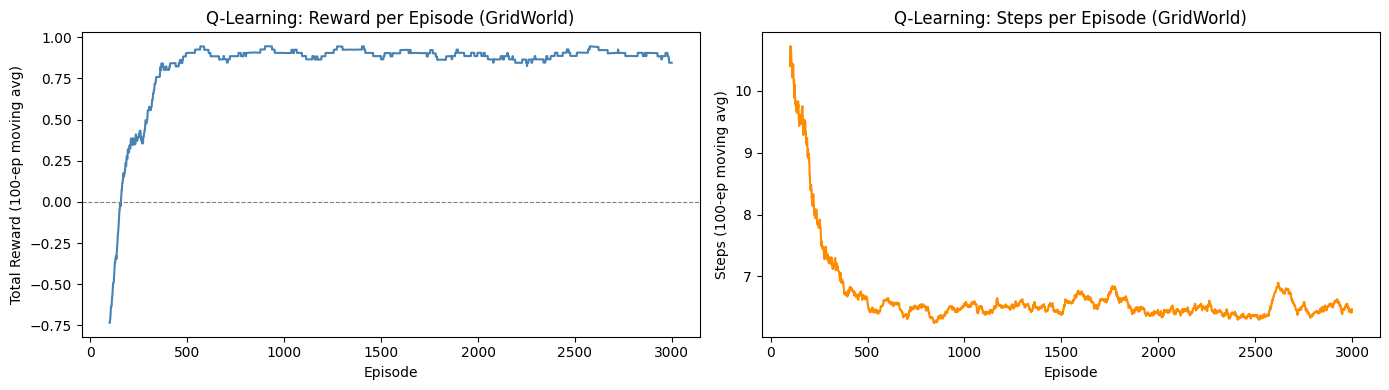

In [6]:
# Q-Learning: Learning curves

# Creates one figure with 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Reward per episode (smoothed)
# pd.Series(ql_reward_history): converts the list of rewards collected during training into a pandas Series
# .rolling(100) : creates a sliding window of 100 episodes
# .mean() : averages the reward over each window
# Without smoothing, the raw reward per episode is extremely noisy, one episode the agent reaches the goal (+1), the next it falls in a hole (-1).
# The rolling average smooths this out so you can actually see the trend.
moving_avg_reward = pd.Series(ql_reward_history).rolling(100).mean()
# Plots the smoothed reward curve on the left plot in steel blue.
axes[0].plot(moving_avg_reward, color='steelblue')
# Labels for the plot i.e title, x-axis, y-axis. Straightforward.
axes[0].set_title("Q-Learning: Reward per Episode (GridWorld)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (100-ep moving avg)")
# Draws a horizontal dashed gray line at y=0. This is a reference line :it makes it easy to see when the agent transitions from performing badly (negative rewards from falling in holes)
# to performing well (positive rewards from reaching the goal). When the curve crosses above this line, the agent has started learning.
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Steps per episode (smoothed), convergence indicator
# Early training: agent wanders randomly, takes 50–100 steps per episode before accidentally reaching goal or hole
# Late training: agent has learned the optimal path, consistently reaches goal in 6–8 steps
# So a decreasing and stabilizing steps curve is direct empirical evidence that the Q-values have converged, exactly what Watkins & Dayan (1992) prove theoretically.
# When the steps curve flattens out, the agent has found and settled on its optimal policy.
# Same smoothing logic as above but for steps taken per episode instead of reward.
moving_avg_steps = pd.Series(ql_steps_history).rolling(100).mean()
# Plots the smoothed steps curve on the right plot in orange with labels.
axes[1].plot(moving_avg_steps, color='darkorange')
axes[1].set_title("Q-Learning: Steps per Episode (GridWorld)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps (100-ep moving avg)")

# automatically adjusts spacing between the two plots so they don't overlap.
plt.tight_layout()
# renders and displays the figure.
plt.show()

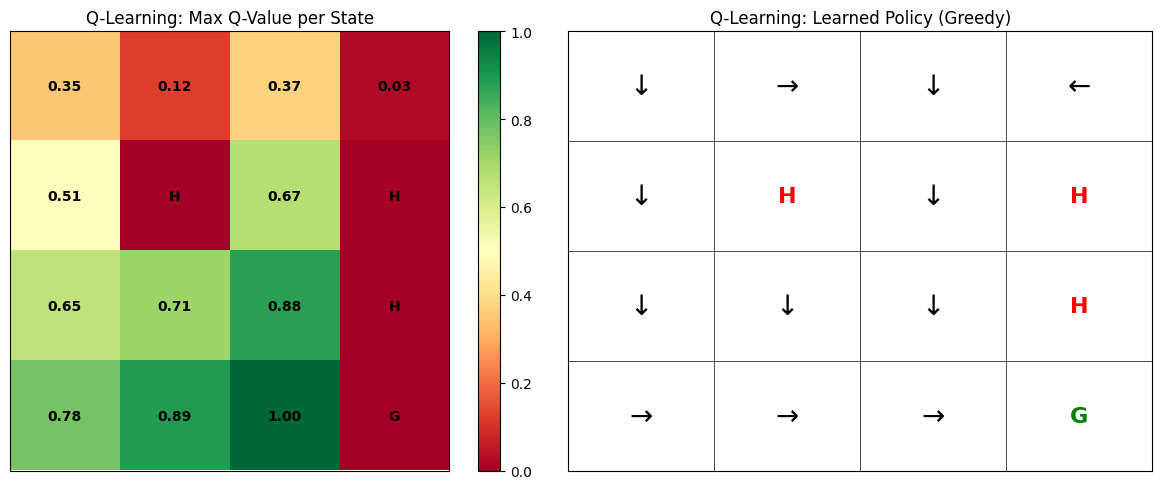

In [7]:
# Q-Learning: Q-value heatmap and learned policy

ACTION_ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
SIZE = env.size

# Two plots side by side. Left = heatmap, Right = policy grid.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap: max Q-value per state
# np.max(agent_ql.q_table, axis=1): for each state (row), take the highest Q-value across all 4 actions. Result is a 1D array of 16 values
# .reshape(SIZE, SIZE) : reshapes that flat array of 16 into a 4×4 grid so it matches the visual layout of GridWorld
max_q_values = np.max(agent_ql.q_table, axis=1).reshape(SIZE, SIZE)
# imshow: displays the 4×4 array as a colored image
# cmap='RdYlGn': Red-Yellow-Green colormap. Low values = red, medium = yellow, high = green. States near the goal will be green, states near holes will be red
# interpolation='nearest': keeps cell boundaries sharp instead of blurring between them
im = axes[0].imshow(max_q_values, cmap='RdYlGn', interpolation='nearest')
# Adds a color scale bar on the side of the heatmap so you can read what value each color corresponds to.
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Q-Learning: Max Q-Value per State")

# Nested loop over all 16 cells.
for r in range(SIZE):
    for c in range(SIZE):
        # Converts (row, col) back to state number.
        state = r * SIZE + c
        # Decides what text to show in each cell
        if state == env.goal:
            label = 'G'
        elif state in env.holes:
            label = 'H'
        else:
            # Every other state: show its max Q-value rounded to 2 decimal places.
            label = f"{max_q_values[r, c]:.2f}"
        # Places the label text in the center of each cell.
        axes[0].text(c, r, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Removes axis tick marks
axes[0].set_xticks([])
axes[0].set_yticks([])

# Policy grid: greedy action per state
# Sets the visible range of the plot to exactly fit the 4×4 grid. The -0.5 and 3.5 boundaries center the grid lines around each cell.
axes[1].set_xlim(-0.5, SIZE - 0.5)
axes[1].set_ylim(-0.5, SIZE - 0.5)
# Title and remove tick marks
axes[1].set_title("Q-Learning: Learned Policy (Greedy)")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].invert_yaxis()
# Flips the y-axis so row 0 is at the TOP.
# By default matplotlib puts row 0 at the bottom, but GridWorld has state 0 at the top-left.
# Iterating over all 16 cells.
for r in range(SIZE):
    for c in range(SIZE):
        # Converts (row, col) back to state number.
        state = r * SIZE + c
        # Decides what text to show in each cell
        if state == env.goal:
            axes[1].text(c, r, 'G', ha='center', va='center', fontsize=16,
                         color='green', fontweight='bold')
        elif state in env.holes:
            axes[1].text(c, r, 'H', ha='center', va='center', fontsize=16,
                         color='red', fontweight='bold')
        else:
            # For every normal state:
            # np.argmax(agent_ql.q_table[state]): finds which action has the highest Q-value for this state
            # ACTION_ARROWS[best_action]: converts that action number to an arrow symbol
            # Plots the arrow in the center of the cell
            # This is the greedy policy: what the agent would actually do if it always picked its best known action.
            # The arrows should form a logical path from state 0 to state 15 avoiding the holes.
            best_action = int(np.argmax(agent_ql.q_table[state]))
            axes[1].text(c, r, ACTION_ARROWS[best_action], ha='center',
                         va='center', fontsize=20)

# Draw grid lines
for x in range(SIZE + 1):
    # Draws 5 horizontal lines and 5 vertical lines to create the grid.
    axes[1].axhline(x - 0.5, color='black', linewidth=0.5)
    axes[1].axvline(x - 0.5, color='black', linewidth=0.5)

# Adjust spacing and display.
plt.tight_layout()
plt.show()

Heatmap:

- States close to goal : high positive values -> green
- States adjacent to holes : low or negative values -> red/yellow
- State 0 (start) : moderate value -> yellowish

Policy grid:

- Arrows form a clear path from top-left to bottom-right
- States near holes have arrows pointing away from them
- The arrows look logical and consistent, which confirms that Q-values have converged correctly

Q-Learning Evaluation (500 greedy episodes): {'Win': 500, 'Loss': 0}
Win rate: 100.0%


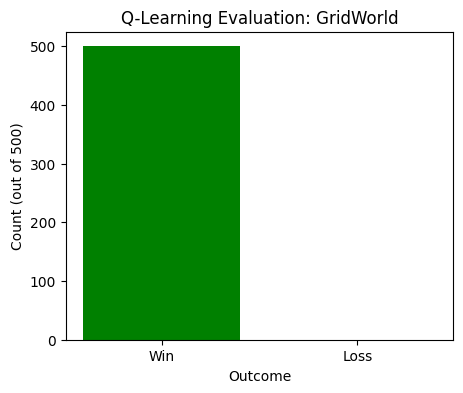

In [8]:
# Evaluate Q-Learning performance

# agent: Trained agent to evaluate
# env_class — Environment class (GridWorld) passed in so a fresh environment can be created inside
# games=500 — Number of episodes to test over. 500 gives a reliable win rate estimate
def evaluate_performance(agent, env_class, games=500):
    # Creates a new GridWorld environment specifically for evaluation.
    env_eval = env_class()
    # A dictionary to count outcomes. Win = reached goal, Loss = fell in hole. Starts at 0 for both.
    results = {"Win": 0, "Loss": 0}
    # saved_epsilon stores the current epsilon value so it can be restored afterward
    saved_epsilon = agent.epsilon
    # agent.epsilon = 0.0 forces the agent to be 100% greedy, no random exploration at all
    # This matters because during training the agent still explores 10% of the time (epsilon_min = 0.1).
    # If you evaluated with epsilon = 0.1, you'd sometimes see random bad moves that don't reflect what the agent actually learned.
    # Setting epsilon to 0 means every action chosen is the single best action the agent knows, a pure test of the learned Q-table.
    agent.epsilon = 0.0

    # Runs 500 complete episodes.
    for _ in range(games):
        # Same structure as the training loop but simpler, no update() call anywhere. The agent is only acting, not learning.
        state = env_eval.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            state, reward, done = env_eval.step(action)
        # After each episode ends, reward holds the final reward received:
        # +1.0 (goal) → reward > 0 : Win
        # -1.0 (hole) → reward not > 0 : Loss
        # step penalty (-0.01) never triggers this because the loop only checks reward after done=True, which only happens at goal or hole.
        if reward > 0:
            results["Win"] += 1
        else:
            results["Loss"] += 1

    # Restores epsilon back to what it was before evaluation (0.1)
    # If this is skipped and evaluate_performance is called during training, epsilon would stay at 0.0 and the agent would stop exploring entirely, breaking the convergence guarantee.
    agent.epsilon = saved_epsilon
    # Returns the dictionary with Win and Loss counts.
    return results

# Runs 500 greedy episodes and stores the result dictionary.
ql_results = evaluate_performance(agent_ql, GridWorld, games=500)
# Prints the raw counts e.g. {'Win': 500, 'Loss': 0}
print("Q-Learning Evaluation (500 greedy episodes):", ql_results)
# Calculates win rate as a percentage: wins divided by total games × 100
print(f"Win rate: {ql_results['Win'] / 500 * 100:.1f}%")

# Bar chart
plt.figure(figsize=(5, 4))
# ql_results.keys(): ['Win', 'Loss'] → x-axis labels
# ql_results.values(): [500, 0] → bar heights
# color=['green', 'red']: Win bar is green, Loss bar is red
plt.bar(ql_results.keys(), ql_results.values(), color=['green', 'red'])
plt.title("Q-Learning Evaluation: GridWorld")
plt.xlabel("Outcome")
plt.ylabel("Count (out of 500)")
plt.show()

---
## 3. SARSA (State-Action-Reward-State-Action)

SARSA is an on-policy TD control algorithm. The key difference from Q-Learning is in the update target. Instead of using the maximum Q-value of the next state, SARSA uses the Q-value of the next action actually chosen by the epsilon-greedy policy. This means if the agent happens to pick a random bad action during exploration, that bad Q-value influences the update. SARSA learns the value of the policy it is actually following, not the optimal policy. This makes it more conservative — it learns to avoid not just holes, but also states near holes because exploratory steps there pulled down the Q-values.

The update rule is:
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma Q(s', a') - Q(s, a) \right]$$
where:

s — current state

a — action taken in s

r — reward received

s′ — next state

a′ — next action actually chosen under the current epsilon-greedy policy

α — fixed learning rate (0.1)

γ — discount factor (0.9)

Q(s,a) — current Q-value estimate

r+γQ(s′,a′) — TD target

r+γQ(s′,a′)−Q(s,a) — TD error (how wrong the current estimate is)


The key distinction from Q-Learning is in the TD target.

Q-Learning uses:
$$\text{target} = r + \gamma \max_{b} Q(s', b)$$

SARSA uses:
$$\text{target} = r + \gamma Q(s', a')$$

where a′ is sampled from the epsilon-greedy policy, not taken as the greedy max.


In [9]:
# The structure is almost identical to Q-Learning except for two things.
# First, alpha is a fixed value of 0.1.
# Second, the update method takes one extra argument: next_action.
# Instead of taking the max over next state Q-values, it looks up the Q-value of the specific action already chosen.
class SARSA:
    # Setting up the agent.
    # gamma (discount factor) = 0.9 i.e Future rewards are worth 90% of immediate rewards. This is the γ in the paper's equation.
    # epsilon (exploration rate) = 1.0, starts at 1.0 i.e the agent explores randomly 100% of the time at the beginning.
    # epsilon_decay = 0.995 i.e after each episode, epsilon is multiplied by 0.995 so exploration gradually reduces.
    # epsilon_min = 0.05 i.e SARSA doesn't need the stricter exploration floor because the convergence theorem being reproduced belongs to Q-Learning, not SARSA
    # alpha is stored as a fixed value
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        # Creates a 16×4 table of zeros.
        # Q-table: rows = states, cols = actions, initialized to 0 (because the agent knows nothing yet.)
        # Each cell holds the agent's current estimate of "how good is it to take action A from state S".
        self.q_table = np.zeros((n_states, n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.n_actions = n_actions

    # How the agent picks a move.
    # Epsilon-greedy: explore randomly or exploit best known action
    def choose_action(self, state):
        # Generates a random number between 0 and 1.
        # If it's less than epsilon, pick a completely random action.
        # Early in training epsilon is 1.0 so this happens 100% of the time,so the agent is just wandering around randomly.
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        # else pick the action with the highest Q-value for the current state.
        # np.argmax returns the index of the highest value in that row of the Q-table.
        # As training progresses and epsilon decays, this happens more and more often.
        return int(np.argmax(self.q_table[state]))

    # The core learning step.
    # this function takes one extra argument compared to Q-Learning's update: next_action. This is the actual action the agent has already decided to take in the next state.
    # Q-Learning's update never needed this because it always assumed the best action, SARSA needs it because it uses the actual chosen action.
    def update(self, state, action, reward, next_state, next_action, done):
        current_q = self.q_table[state][action]

        # If episode ended, target is just the final reward
        if done:
            target = reward
        else:
            # Key SARSA difference: # uses the ACTUALLY CHOSEN action, whatever epsilon-greedy picked
            # If epsilon-greedy happened to pick a random bad action for next_action, that bad Q-value gets used in the target.
            # This means SARSA's Q-values reflect the real behavior of the agent including its exploration mistakes, making it more conservative than Q-Learning.
            target = reward + self.gamma * self.q_table[next_state][next_action]


        # (target - current_q) : the TD error i.e how wrong the current estimate is
        # alpha * (TD error) : a small correction proportional to how wrong it was
        # Add that correction to the current Q-value
        # If target > current_q: Q-value goes up ,this was better than expected
        # If target < current_q: Q-value goes down, this was worse than expected
        # Over thousands of updates, Q-values converge to the true values.
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

    # Reduce exploration over time
    # After each episode: multiply epsilon by 0.995.
    # But never let it go below 0.05. So the agent explores less and less as it learns, but never stops exploring completely
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [10]:
# SARSA training

# Fresh environment, fresh agent
env = GridWorld()
agent_sarsa = SARSA(n_states=env.n_states, n_actions=env.n_actions)

episodes = 3000

# total reward
sarsa_reward_history = []
# total steps for every episode
sarsa_steps_history = []

# Runs 3000 times. Each iteration = one complete game.
for ep in range(episodes):
    # Puts the agent back at state 0 and returns 0. Called at the start of every episode so each game starts fresh.
    state = env.reset()
    # tracks whether the episode has ended (goal or hole reached)
    done = False
    # accumulates all rewards received in this episode
    total_reward = 0
    # counts how many moves the agent made this episode
    steps = 0

    # SARSA requires choosing the first action before the loop
    action = agent_sarsa.choose_action(state)

    # Keeps running until the episode ends. Each iteration = one move.
    while not done:
        # Environment executes the action and returns three things:
        # next_state: where the agent ended up after the move
        # reward: +1 (goal), -1 (hole), or -0.01 (normal step)
        # done: True if episode ended, False if still going
        next_state, reward, done = env.step(action)

        # Choose next action before updating (on-policy)
        # Before updating, SARSA immediately chooses the next action from the next state. This is what makes it on-policy — the next action is chosen right now using the current epsilon-greedy policy,
        # and that same action will be passed into the update AND used as the action in the next iteration. When done=True, the episode is over so there is no next action to actually take.
        # The placeholder value 0 is passed in but the update function ignores it completely when done=True because the target is just reward with no next Q-value.
        if not done:
            next_action = agent_sarsa.choose_action(next_state)
        else:
            next_action = 0  # placeholder: not used when done=True

        # Calls the update with all five pieces of information.
        # The core learning step. Passes everything the agent needs to update its Q-table:
        # Where it was (state), What it did (action), What it got (reward), Where it ended up (next_state), Whether the game ended (done)
        # Internally this increments visit count, computes alpha = 1/N, and updates the Q-value
        agent_sarsa.update(state, action, reward, next_state, next_action, done)

        # Move forward : the next state becomes the current state for the next iteration. Without this line the agent would be stuck at state 0 forever.
        state = next_state
        # The action chosen right now becomes the action executed at the start of the next iteration.
        action = next_action
        # Accumulate the reward and count the step for this episode.
        total_reward += reward
        steps += 1

    # Called once per episode after the inner loop finishes.The agent gradually shifts from exploring to exploiting over the 3000 episodes.
    agent_sarsa.decay_epsilon()
    # After 3000 episodes these lists have 3000 values each, one per episode, which get smoothed and plotted in the learning curves.
    sarsa_reward_history.append(total_reward)
    sarsa_steps_history.append(steps)

# Shows where epsilon ended up after 3000 episodes of decay. Should be 0.05 (the floor).
print("SARSA training complete.")
print(f"Final epsilon: {agent_sarsa.epsilon:.4f}")
# Averaging these tells you how well the agent is performing after it has converged.
print(f"Avg reward (last 200 eps): {np.mean(sarsa_reward_history[-200:]):.4f}")
print(f"Avg steps  (last 200 eps): {np.mean(sarsa_steps_history[-200:]):.1f}")

SARSA training complete.
Final epsilon: 0.0500
Avg reward (last 200 eps): 0.9071
Avg steps  (last 200 eps): 6.3


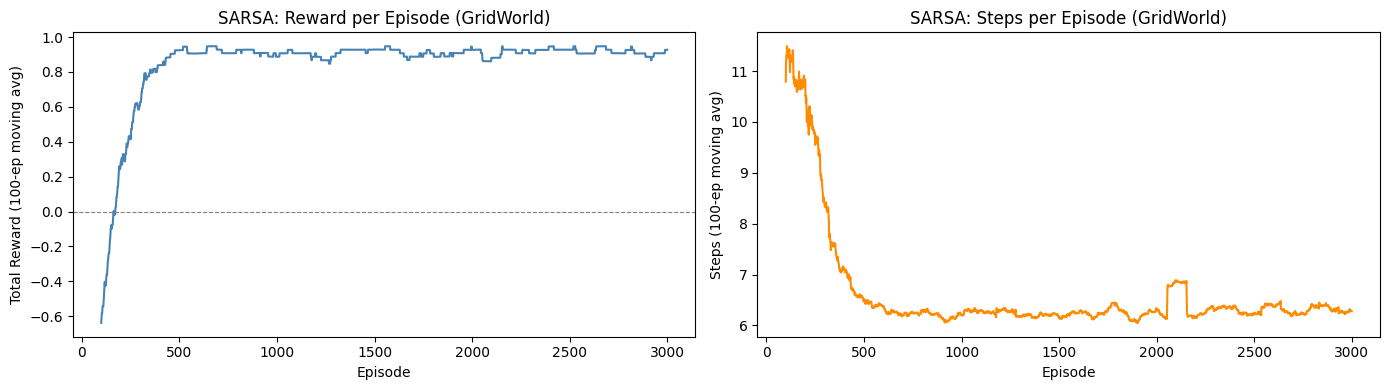

In [11]:
# SARSA: Learning curves

# Creates one figure with 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Reward per episode (smoothed)
# pd.Series(ql_reward_history): converts the list of rewards collected during training into a pandas Series
# .rolling(100) : creates a sliding window of 100 episodes
# .mean() : averages the reward over each window
# Without smoothing, the raw reward per episode is extremely noisy, one episode the agent reaches the goal (+1), the next it falls in a hole (-1).
# The rolling average smooths this out so you can actually see the trend.
moving_avg_reward = pd.Series(sarsa_reward_history).rolling(100).mean()
# Plots the smoothed reward curve on the left plot in steel blue.
axes[0].plot(moving_avg_reward, color='steelblue')
# Labels for the plot i.e title, x-axis, y-axis. Straightforward.
axes[0].set_title("SARSA: Reward per Episode (GridWorld)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (100-ep moving avg)")
# Draws a horizontal dashed gray line at y=0. This is a reference line :it makes it easy to see when the agent transitions from performing badly (negative rewards from falling in holes)
# to performing well (positive rewards from reaching the goal). When the curve crosses above this line, the agent has started learning.
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Steps per episode (smoothed), convergence indicator
# Early training: agent wanders randomly, takes 50–100 steps per episode before accidentally reaching goal or hole
# Late training: agent has learned the optimal path, consistently reaches goal in 6–8 steps
# So a decreasing and stabilizing steps curve is direct empirical evidence that the Q-values have converged, exactly what Watkins & Dayan (1992) prove theoretically.
# When the steps curve flattens out, the agent has found and settled on its optimal policy.
# Same smoothing logic as above but for steps taken per episode instead of reward.
moving_avg_steps = pd.Series(sarsa_steps_history).rolling(100).mean()
# Plots the smoothed steps curve on the right plot in orange with labels.
axes[1].plot(moving_avg_steps, color='darkorange')
axes[1].set_title("SARSA: Steps per Episode (GridWorld)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps (100-ep moving avg)")

# automatically adjusts spacing between the two plots so they don't overlap.
plt.tight_layout()
# renders and displays the figure.
plt.show()

**Reward curve:**

SARSA typically learns slightly slower than Q-Learning early on. Because SARSA is on-policy, exploratory mistakes directly affect Q-values, a random bad action during exploration pulls Q-values down. Q-Learning ignores those random actions in its update so it can be more aggressive early. You may see SARSA's reward curve rise more gradually.


**Steps curve:**

SARSA tends to settle on a slightly more cautious path than Q-Learning. In GridWorld this might mean SARSA takes 7–8 steps consistently while Q-Learning takes 6–7. SARSA learns to avoid not just the holes themselves but also states near the holes, because exploratory steps near holes have influenced its Q-values during training.

SARSA Evaluation (500 greedy episodes): {'Win': 500, 'Loss': 0}
Win rate: 100.0%


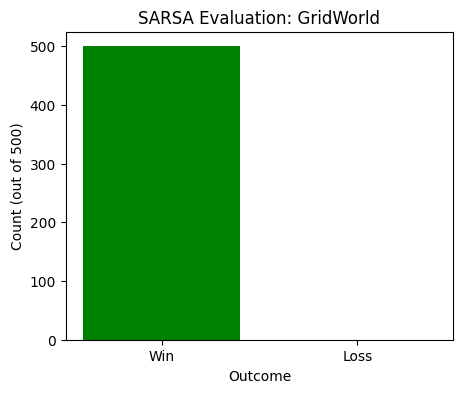

In [12]:
# Evaluate SARSA

# The evaluate_performance function defined earlier is being reused here
# Creates a fresh GridWorld
# Saves and sets epsilon to 0.0
# Runs 500 greedy episodes
# Counts wins and losses
# Restores epsilon back to 0.05
sarsa_results = evaluate_performance(agent_sarsa, GridWorld, games=500)
# Prints the raw counts e.g. {'Win': 500, 'Loss': 0}
print("SARSA Evaluation (500 greedy episodes):", sarsa_results)
# Calculates win rate as a percentage: wins divided by total games × 100
print(f"Win rate: {sarsa_results['Win'] / 500 * 100:.1f}%")

# Bar chart
plt.figure(figsize=(5, 4))
plt.bar(sarsa_results.keys(), sarsa_results.values(), color=['green', 'red'])
plt.title("SARSA Evaluation: GridWorld")
plt.xlabel("Outcome")
plt.ylabel("Count (out of 500)")
plt.show()


 Q-Learning cuts closer to holes while SARSA gives them a wider berth because SARSA's Q-values near holes were dragged down by exploratory mistakes during training, making those states look less attractive even when the agent is being greedy.

---
## 4. Expected SARSA


Expected SARSA is an on-policy TD control algorithm that reduces variance by averaging over all possible next actions weighted by how likely the current policy is to choose each one. It uses the expected Q-value across all actions, weighted by the epsilon-greedy probabilities. The greedy action gets probability (1 minus epsilon) plus epsilon divided by the number of actions. Every other action gets epsilon divided by the number of actions. This averaging removes the variance from SARSA while remaining on-policy.

The update rule is:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \sum_{a'} \pi(a'|s') Q(s', a') - Q(s, a) \right]$$


where π(a′∣s′) is the probability of choosing action a′ in state s′ under the current epsilon-greedy policy:

$$\pi(a'|s') = \begin{cases} (1 - \varepsilon) + \dfrac{\varepsilon}{|A|} & \text{if } a' = \arg\max_b Q(s', b) \\ \dfrac{\varepsilon}{|A|} & \text{otherwise} \end{cases}$$

where:

ε — current exploration rate

∣A∣ — total number of actions (4 in GridWorld)

argmaxb​Q(s′,b) — the greedy best action in the next state

So the greedy action gets probability $(1 - \varepsilon) + \varepsilon/|A|$ and every
other action gets probability $\varepsilon/|A|$. All probabilities sum to 1.

The expected Q-value of the next state is then:

$$\mathbb{E}_\pi[Q(s', a')] = \sum_{a'} \pi(a'|s') Q(s', a')$$

This replaces the single sampled $Q(s', a')$ in SARSA and the $\max_b Q(s', b)$
in Q-Learning.

The result is an update that is less noisy than SARSA because randomness in action selection is averaged out mathematically rather than left to chance, while still remaining on-policy because the probabilities reflect the actual epsilon-greedy policy being followed.

In [13]:
# EXPECTED SARSA

class ExpectedSARSA:
    # Setting up the agent.
    # gamma (discount factor) = 0.9 i.e Future rewards are worth 90% of immediate rewards. This is the γ in the paper's equation.
    # epsilon (exploration rate) = 1.0, starts at 1.0 i.e the agent explores randomly 100% of the time at the beginning.
    # epsilon_decay = 0.995 i.e after each episode, epsilon is multiplied by 0.995 so exploration gradually reduces.
    # epsilon_min = 0.05 i.e SARSA doesn't need the stricter exploration floor because the convergence theorem being reproduced belongs to Q-Learning, not SARSA
    # alpha is stored as a fixed value
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        # Creates a 16×4 table of zeros.
        # Q-table: rows = states, cols = actions, initialized to 0 (because the agent knows nothing yet.)
        # Each cell holds the agent's current estimate of "how good is it to take action A from state S".
        self.q_table = np.zeros((n_states, n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.n_actions = n_actions


    # How the agent picks a move.
    # Epsilon-greedy: explore randomly or exploit best known action
    def choose_action(self, state):
        # Generates a random number between 0 and 1.
        # If it's less than epsilon, pick a completely random action.
        # Early in training epsilon is 1.0 so this happens 100% of the time,so the agent is just wandering around randomly.
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        # else pick the action with the highest Q-value for the current state.
        # np.argmax returns the index of the highest value in that row of the Q-table.
        # As training progresses and epsilon decays, this happens more and more often.
        return int(np.argmax(self.q_table[state]))

    # The core learning step.
    # Takes a state and returns a single number: the expected Q-value of that state under the current epsilon-greedy policy.
    # This is Eπ​[Q(s′,a′)] from the formula.
    def expected_q_value(self, state):
        # Gets the full row of Q-values for this state — all 4 action values.
        q_values = self.q_table[state]
        # Finds which action has the highest Q-value.
        best_action = int(np.argmax(q_values))

        # Build probability vector for epsilon-greedy
        # Creates a probability array of length 4, giving every action the same base probability of ε/∣A∣.
        probs = np.ones(self.n_actions) * (self.epsilon / self.n_actions)
        # Adds the greedy probability (1−ε) on top of the base probability for the best action only.
        # This is the greedy action, argmaxb​Q(s′,b).
        probs[best_action] += (1.0 - self.epsilon)

        # Expected Q = sum over all actions of (prob * Q-value)
        # np.dot multiplies each probability by its corresponding Q-value and sums everything up.
        # This is ∑a′​π(a′∣s′)Q(s′,a′) from the formula.
        return np.dot(probs, q_values)


    # no next_action needed because the expectation is computed mathematically over all actions.
    def update(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]

        # If episode ended, target is just the final reward
        if done:
            target = reward
        else:
            # Key Expected SARSA difference: uses weighted average Q-value, on-policy and less noisy
            target = reward + self.gamma * self.expected_q_value(next_state)

        # (target - current_q) : the TD error i.e how wrong the current estimate is
        # alpha * (TD error) : a small correction proportional to how wrong it was
        # Add that correction to the current Q-value
        # If target > current_q: Q-value goes up ,this was better than expected
        # If target < current_q: Q-value goes down, this was worse than expected
        # Over thousands of updates, Q-values converge to the true values.
        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

    # Reduce exploration over time
    # After each episode: multiply epsilon by 0.995.
    # But never let it go below 0.05. So the agent explores less and less as it learns, but never stops exploring completely
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [14]:
# Expected SARSA training

# Fresh environment, fresh agent
env = GridWorld()
agent_esarsa = ExpectedSARSA(n_states=env.n_states, n_actions=env.n_actions)


episodes = 3000
# total reward
esarsa_reward_history = []
# total steps for every episode
esarsa_steps_history = []

# Runs 3000 times. Each iteration = one complete game.
for ep in range(episodes):
    # Puts the agent back at state 0 and returns 0. Called at the start of every episode so each game starts fresh.
    state = env.reset()
    # tracks whether the episode has ended (goal or hole reached)
    done = False
    # accumulates all rewards received in this episode
    total_reward = 0
    # counts how many moves the agent made this episode
    steps = 0

    # Keeps running until the episode ends. Each iteration = one move.
    # Action is chosen inside the loop, same as Q-Learning.
    while not done:
        action = agent_esarsa.choose_action(state)
        # Environment executes the action and returns three things:
        # next_state: where the agent ended up after the move
        # reward: +1 (goal), -1 (hole), or -0.01 (normal step)
        # done: True if episode ended, False if still going
        next_state, reward, done = env.step(action)

        # Calls the update with all pieces of information.
        # The core learning step. Passes everything the agent needs to update its Q-table:
        # Where it was (state), What it did (action), What it got (reward), Where it ended up (next_state), Whether the game ended (done)
        # Internally this increments visit count, computes alpha = 1/N, and updates the Q-value
        # Expected SARSA's update signature looks identical to Q-Learning but what happens inside is completely different.
        # Instead of taking the max, it calls expected_q_value() which computes the weighted average across all actions under the current policy.
        agent_esarsa.update(state, action, reward, next_state, done)

        # Move forward : the next state becomes the current state for the next iteration. Without this line the agent would be stuck at state 0 forever.
        state = next_state
        # Accumulate the reward and count the step for this episode.
        total_reward += reward
        steps += 1

    # Called once per episode after the inner loop finishes.The agent gradually shifts from exploring to exploiting over the 3000 episodes.
    agent_esarsa.decay_epsilon()
    # After 3000 episodes these lists have 3000 values each, one per episode, which get smoothed and plotted in the learning curves.
    esarsa_reward_history.append(total_reward)
    esarsa_steps_history.append(steps)

# Shows where epsilon ended up after 3000 episodes of decay. Should be 0.05 (the floor).
print("Expected SARSA training complete.")
print(f"Final epsilon: {agent_esarsa.epsilon:.4f}")
# Averaging these tells you how well the agent is performing after it has converged.
print(f"Avg reward (last 200 eps): {np.mean(esarsa_reward_history[-200:]):.4f}")
print(f"Avg steps  (last 200 eps): {np.mean(esarsa_steps_history[-200:]):.1f}")

Expected SARSA training complete.
Final epsilon: 0.0500
Avg reward (last 200 eps): 0.9078
Avg steps  (last 200 eps): 6.2


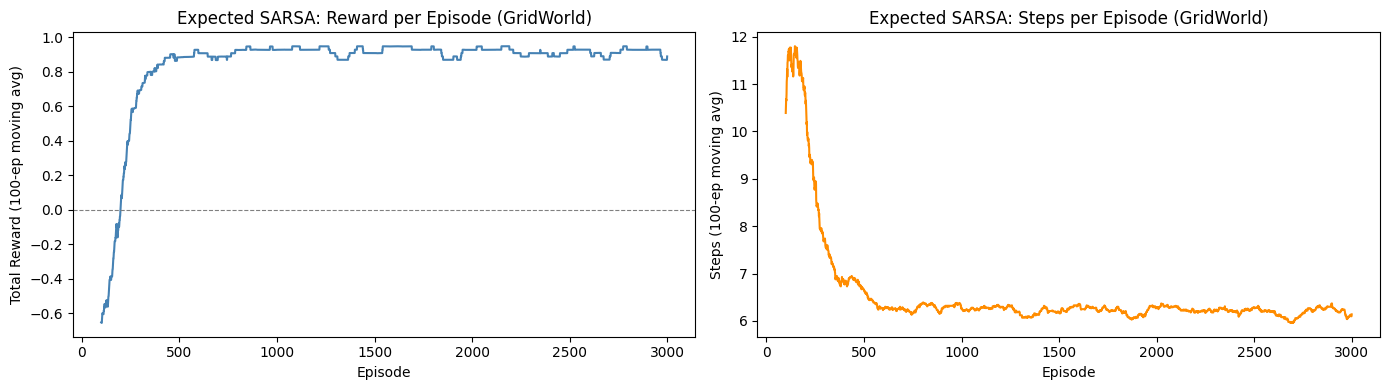

In [15]:
# Expected SARSA: Learning curves

# Creates one figure with 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Reward per episode (smoothed)
# pd.Series(ql_reward_history): converts the list of rewards collected during training into a pandas Series
# .rolling(100) : creates a sliding window of 100 episodes
# .mean() : averages the reward over each window
# Without smoothing, the raw reward per episode is extremely noisy, one episode the agent reaches the goal (+1), the next it falls in a hole (-1).
# The rolling average smooths this out so you can actually see the trend.
moving_avg_reward = pd.Series(esarsa_reward_history).rolling(100).mean()
# Plots the smoothed reward curve on the left plot in steel blue.
axes[0].plot(moving_avg_reward, color='steelblue')
# Labels for the plot i.e title, x-axis, y-axis. Straightforward.
axes[0].set_title("Expected SARSA: Reward per Episode (GridWorld)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (100-ep moving avg)")
# Draws a horizontal dashed gray line at y=0. This is a reference line :it makes it easy to see when the agent transitions from performing badly (negative rewards from falling in holes)
# to performing well (positive rewards from reaching the goal). When the curve crosses above this line, the agent has started learning.
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Steps per episode (smoothed), convergence indicator
# Early training: agent wanders randomly, takes 50–100 steps per episode before accidentally reaching goal or hole
# Late training: agent has learned the optimal path, consistently reaches goal in 6–8 steps
# So a decreasing and stabilizing steps curve is direct empirical evidence that the Q-values have converged, exactly what Watkins & Dayan (1992) prove theoretically.
# When the steps curve flattens out, the agent has found and settled on its optimal policy.
# Same smoothing logic as above but for steps taken per episode instead of reward.
moving_avg_steps = pd.Series(esarsa_steps_history).rolling(100).mean()
# Plots the smoothed steps curve on the right plot in orange with labels.
axes[1].plot(moving_avg_steps, color='darkorange')
axes[1].set_title("Expected SARSA: Steps per Episode (GridWorld)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps (100-ep moving avg)")

# automatically adjusts spacing between the two plots so they don't overlap.
plt.tight_layout()
# renders and displays the figure.
plt.show()

**Reward curve:**
Expected SARSA converges similarly to Q-Learning in speed but more smoothly than SARSA because the update averages over all actions rather than sampling one random action, the reward curve has less noise episode to episode, the mathematical averaging removes the variance that made SARSA's curve jagged.


**Steps curve:**
Expected SARSA settles at roughly the same steps as SARSA, around 6-8 steps,  because both are on-policy and learn a similarly cautious path. However the steps curve for Expected SARSA should be noticeably smoother than SARSA's because again the variance from random action sampling is eliminated mathematically.

Expected SARSA Evaluation (500 greedy episodes): {'Win': 500, 'Loss': 0}
Win rate: 100.0%


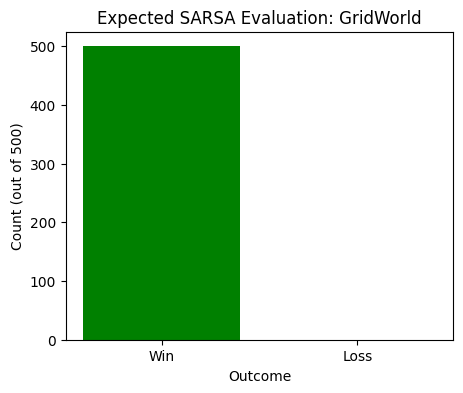

In [16]:
# Evaluate Expected SARSA

# The evaluate_performance function defined earlier is being reused here
# Creates a fresh GridWorld
# Saves and sets epsilon to 0.0
# Runs 500 greedy episodes
# Counts wins and losses
# Restores epsilon back to 0.05
esarsa_results = evaluate_performance(agent_esarsa, GridWorld, games=500)
# Prints the raw counts e.g. {'Win': 500, 'Loss': 0}
print("Expected SARSA Evaluation (500 greedy episodes):", esarsa_results)
# Calculates win rate as a percentage: wins divided by total games × 100
print(f"Win rate: {esarsa_results['Win'] / 500 * 100:.1f}%")

# Bar chart
plt.figure(figsize=(5, 4))
plt.bar(esarsa_results.keys(), esarsa_results.values(), color=['green', 'red'])
plt.title("Expected SARSA Evaluation: GridWorld")
plt.xlabel("Outcome")
plt.ylabel("Count (out of 500)")
plt.show()

## 5. Double Q-Learning

Standard Q-Learning has a known problem called **maximization bias**. When computing
the target, it uses `max` to both select the best action and evaluate it using the same
Q-table. Since Q-values are noisy estimates early in training, always taking the max
consistently overestimates the true value — the agent becomes overconfident about
certain actions.

Double Q-Learning solves this by maintaining **two independent Q-tables**, $Q_1$ and
$Q_2$, and randomly deciding which table does each job on every update. One table
selects the best action, the other evaluates it. This decoupling removes the upward bias.

On each update, with probability 0.5:

$$Q_1(s,a) \leftarrow Q_1(s,a) + \alpha \left[ r + \gamma Q_2(s', \arg\max_b Q_1(s',b)) - Q_1(s,a) \right]$$

Otherwise:

$$Q_2(s,a) \leftarrow Q_2(s,a) + \alpha \left[ r + \gamma Q_1(s', \arg\max_b Q_2(s',b)) - Q_2(s,a) \right]$$

where:
- $Q_1$ and $Q_2$ — two independent Q-tables
- $\arg\max_b Q_1(s', b)$ — action selected by the table being updated
- $Q_2(s', \cdot)$ — the other table evaluates that action
- $r + \gamma Q_2(s', \arg\max_b Q_1(s',b)) - Q_1(s,a)$ — TD error using decoupled selection and evaluation

For action selection, both tables are combined:

$$a = \arg\max_b \left[ Q_1(s, b) + Q_2(s, b) \right]$$

Averaging both tables for action selection gives a more stable and less biased estimate
of the true Q-values than either table alone.

In [17]:
# DOUBLE Q-LEARNING

# Setting up the agent.
# gamma (discount factor) = 0.9 i.e Future rewards are worth 90% of immediate rewards. This is the γ in the paper's equation.
# epsilon (exploration rate) = 1.0, starts at 1.0 i.e the agent explores randomly 100% of the time at the beginning.
# epsilon_decay = 0.995 i.e after each episode, epsilon is multiplied by 0.995 so exploration gradually reduces.
# epsilon_min = 0.05 i.e SARSA doesn't need the stricter exploration floor because the convergence theorem being reproduced belongs to Q-Learning, not SARSA
# alpha=0.1 is stored as a fixed value
class DoubleQLearning:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        # Two Q-tables instead of one
        # Creates a 16×4 table of zeros.
        # Q-table: rows = states, cols = actions, initialized to 0 (because the agent knows nothing yet.)
        # Each cell holds the agent's current estimate of "how good is it to take action A from state S".
        self.q1 = np.zeros((n_states, n_actions))
        self.q2 = np.zeros((n_states, n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.n_actions = n_actions

    # How the agent picks a move.
    # Epsilon-greedy: explore randomly or exploit best known action
    def choose_action(self, state):
        # Generates a random number between 0 and 1.
        # If it's less than epsilon, pick a completely random action.
        # Early in training epsilon is 1.0 so this happens 100% of the time,so the agent is just wandering around randomly.
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        # Use sum of both tables for action selection
        combined = self.q1[state] + self.q2[state]
        # else pick the action with the highest Q-value for the current state.
        # np.argmax returns the index of the highest value in that row of the Q-table.
        # As training progresses and epsilon decays, this happens more and more often.
        return int(np.argmax(combined))

    # The core learning step.
    def update(self, state, action, reward, next_state, done):
        # Randomly decide which table to update
        if random.random() < 0.5:
            # Update Q1: Q1 selects action, Q2 evaluates it
            current_q = self.q1[state][action]
            # If episode ended, target is just the final reward
            if done:
                target = reward
            else:
                # When updating Q1, three steps happen:
                # np.argmax(self.q1[next_state]) : Q1 selects which action looks best
                # self.q2[next_state][best_action] : Q2 evaluates how good that action actually is
                # Update Q1 using that evaluated value
                # This reduces bias because Q1 might overestimate action 2 as the best, but Q2 has an independent estimate of action 2's value.
                # If Q1's enthusiasm for action 2 is just noise, Q2's independent estimate will be more realistic and pull the target back down.
                best_action = int(np.argmax(self.q1[next_state]))
                target = reward + self.gamma * self.q2[next_state][best_action]
            self.q1[state][action] = current_q + self.alpha * (target - current_q)
        else:
            # Now Q2 selects the best action and Q1 evaluates it:
            current_q = self.q2[state][action]
            if done:
                target = reward
            else:
                best_action = int(np.argmax(self.q2[next_state]))
                target = reward + self.gamma * self.q1[next_state][best_action]
            self.q2[state][action] = current_q + self.alpha * (target - current_q)

    # Reduce exploration over time
    # After each episode: multiply epsilon by 0.995.
    # But never let it go below 0.05. So the agent explores less and less as it learns, but never stops exploring completely
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [18]:
# Double Q-Learning training

# Fresh environment, fresh agent
env = GridWorld()
agent_dql = DoubleQLearning(n_states=env.n_states, n_actions=env.n_actions)

episodes = 3000
# total reward
dql_reward_history = []
# total steps for every episode
dql_steps_history = []

# Runs 3000 times. Each iteration = one complete game.
for ep in range(episodes):
    # Puts the agent back at state 0 and returns 0. Called at the start of every episode so each game starts fresh.
    state = env.reset()
    # tracks whether the episode has ended (goal or hole reached)
    done = False
    # accumulates all rewards received in this episode
    total_reward = 0
    # counts how many moves the agent made this episode
    steps = 0

    # Keeps running until the episode ends. Each iteration = one move.
    # Action is chosen inside the loop, same as Q-Learning.
    while not done:
        action = agent_dql.choose_action(state)

        # Environment executes the action and returns three things:
        # next_state: where the agent ended up after the move
        # reward: +1 (goal), -1 (hole), or -0.01 (normal step)
        # done: True if episode ended, False if still going
        next_state, reward, done = env.step(action)

        # Internally this flips a coin, randomly updates either q1 or q2 using the other for evaluation.
        agent_dql.update(state, action, reward, next_state, done)
        # Move forward : the next state becomes the current state for the next iteration. Without this line the agent would be stuck at state 0 forever.
        state = next_state
        # Accumulate the reward and count the step for this episode.
        total_reward += reward
        steps += 1

    # Called once per episode after the inner loop finishes.The agent gradually shifts from exploring to exploiting over the 3000 episodes.
    agent_dql.decay_epsilon()
    # After 3000 episodes these lists have 3000 values each, one per episode, which get smoothed and plotted in the learning curves.
    dql_reward_history.append(total_reward)
    dql_steps_history.append(steps)

# Shows where epsilon ended up after 3000 episodes of decay. Should be 0.05 (the floor).
print("Double Q-Learning training complete.")
print(f"Final epsilon: {agent_dql.epsilon:.4f}")
# Averaging these tells you how well the agent is performing after it has converged.
print(f"Avg reward (last 200 eps): {np.mean(dql_reward_history[-200:]):.4f}")
print(f"Avg steps  (last 200 eps): {np.mean(dql_steps_history[-200:]):.1f}")

Double Q-Learning training complete.
Final epsilon: 0.0500
Avg reward (last 200 eps): 0.8783
Avg steps  (last 200 eps): 6.2


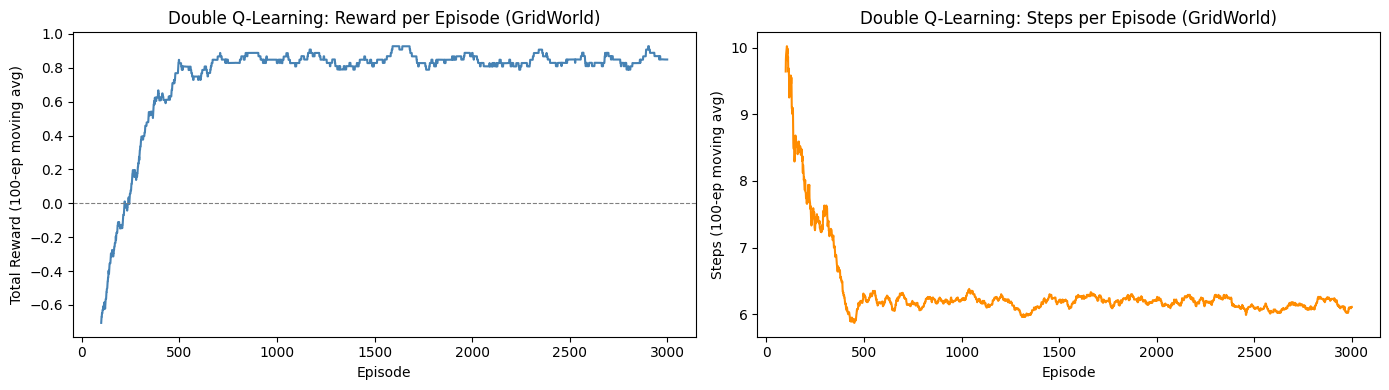

In [19]:
# Double Q-Learning: Learning curves

# Creates one figure with 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Reward per episode (smoothed)
# pd.Series(ql_reward_history): converts the list of rewards collected during training into a pandas Series
# .rolling(100) : creates a sliding window of 100 episodes
# .mean() : averages the reward over each window
# Without smoothing, the raw reward per episode is extremely noisy, one episode the agent reaches the goal (+1), the next it falls in a hole (-1).
# The rolling average smooths this out so you can actually see the trend.
moving_avg_reward = pd.Series(dql_reward_history).rolling(100).mean()
# Plots the smoothed reward curve on the left plot in steel blue.
axes[0].plot(moving_avg_reward, color='steelblue')
# Labels for the plot i.e title, x-axis, y-axis. Straightforward.
axes[0].set_title("Double Q-Learning: Reward per Episode (GridWorld)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (100-ep moving avg)")
# Draws a horizontal dashed gray line at y=0. This is a reference line :it makes it easy to see when the agent transitions from performing badly (negative rewards from falling in holes)
# to performing well (positive rewards from reaching the goal). When the curve crosses above this line, the agent has started learning.
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# Steps per episode (smoothed), convergence indicator
# Early training: agent wanders randomly, takes 50–100 steps per episode before accidentally reaching goal or hole
# Late training: agent has learned the optimal path, consistently reaches goal in 6–8 steps
# So a decreasing and stabilizing steps curve is direct empirical evidence that the Q-values have converged, exactly what Watkins & Dayan (1992) prove theoretically.
# When the steps curve flattens out, the agent has found and settled on its optimal policy.
# Same smoothing logic as above but for steps taken per episode instead of reward.
moving_avg_steps = pd.Series(dql_steps_history).rolling(100).mean()
# Plots the smoothed steps curve on the right plot in orange with labels.
axes[1].plot(moving_avg_steps, color='darkorange')
axes[1].set_title("Double Q-Learning: Steps per Episode (GridWorld)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps (100-ep moving avg)")

# automatically adjusts spacing between the two plots so they don't overlap.
plt.tight_layout()
# renders and displays the figure.
plt.show()

**Reward curve:**

Double Q-Learning learns slightly slower than standard Q-Learning early on. This is expected as by using two tables and randomly updating one at a time, each table receives only half the updates compared to a single Q-table agent. However the reward curve is smoother and more stable once it converges because overestimated Q-values are corrected by the second table.


**Steps curve:**
This settles at roughly the same level as Q-Learning, around 6-8 steps, since both are off-policy and learn aggressive optimal paths. The difference is that Double Q-Learning's path is based on more reliable Q-value estimates rather than potentially inflated ones.

Double Q-Learning Evaluation (500 greedy episodes): {'Win': 500, 'Loss': 0}
Win rate: 100.0%


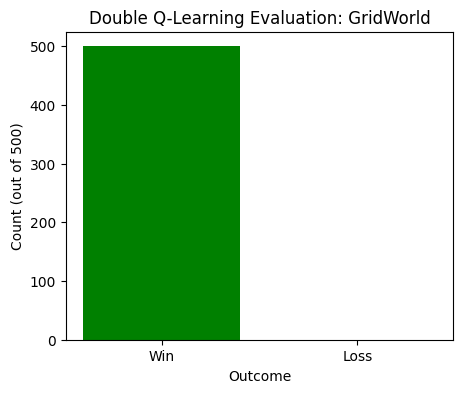

In [20]:
# Evaluate Double Q-Learning

# The evaluate_performance function defined earlier is being reused here
# Creates a fresh GridWorld
# Saves and sets epsilon to 0.0
# Runs 500 greedy episodes
# Counts wins and losses
# Restores epsilon back to 0.05
dql_results = evaluate_performance(agent_dql, GridWorld, games=500)
# Prints the raw counts e.g. {'Win': 500, 'Loss': 0}
print("Double Q-Learning Evaluation (500 greedy episodes):", dql_results)
# Calculates win rate as a percentage: wins divided by total games × 100
print(f"Win rate: {dql_results['Win'] / 500 * 100:.1f}%")

# Bar chart
plt.figure(figsize=(5, 4))
plt.bar(dql_results.keys(), dql_results.values(), color=['green', 'red'])
plt.title("Double Q-Learning Evaluation: GridWorld")
plt.xlabel("Outcome")
plt.ylabel("Count (out of 500)")
plt.show()

---
## 6. Algorithm Comparison

All four algorithms were trained under identical conditions:

same GridWorld environment,


same hyperparameters (γ = 0.9, ε₀ = 1.0, decay = 0.995) : Q-Learning uses
α = 1/N(x,a) per the theorem, while SARSA, Expected SARSA, and Double Q-Learning
use fixed α = 0.1

This ensures any differences in performance are due to the
algorithms themselves, not the experimental setup.

The four algorithms differ in exactly one thing: how they compute the TD target:

**Q-Learning** (off-policy):
$$\text{target} = r + \gamma \max_{b} Q(s', b)$$

**SARSA** (on-policy):
$$\text{target} = r + \gamma Q(s', a')$$

**Expected SARSA** (on-policy):
$$\text{target} = r + \gamma \sum_{a'} \pi(a'|s') Q(s', a')$$

**Double Q-Learning** (off-policy):
$$\text{target} = r + \gamma Q_2(s', \arg\max_b Q_1(s', b))$$

Everything else,i.e, the update rule, the epsilon-greedy action selection, the episode
structure, is identical across all four. The comparison therefore isolates the effect
of the target computation on learning speed, stability, and final performance.

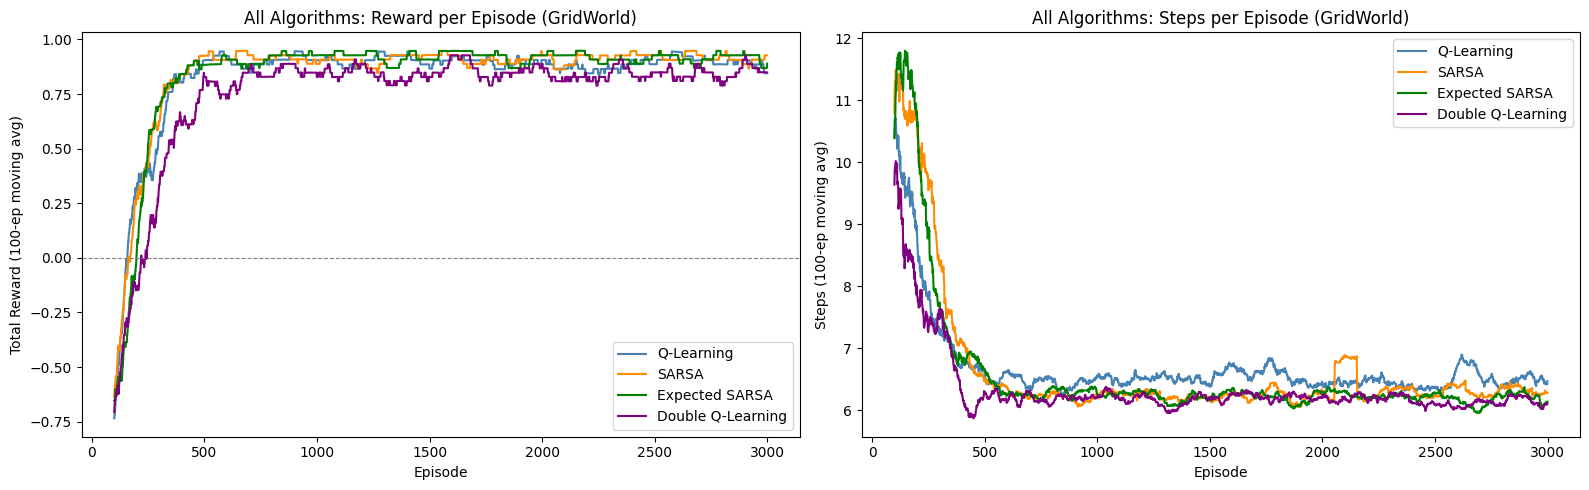

In [21]:

labels = ['Q-Learning', 'SARSA', 'Expected SARSA', 'Double Q-Learning']
# Packages all four reward history lists into one list.
reward_histories = [ql_reward_history, sarsa_reward_history,
                    esarsa_reward_history, dql_reward_history]
# Packages all four step history lists into one list.
steps_histories  = [ql_steps_history,  sarsa_steps_history,
                    esarsa_steps_history, dql_steps_history]
# One distinct color per algorithm. Same order as labels.
colors = ['steelblue', 'darkorange', 'green', 'purple']

# Two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# zip(reward_histories, labels, colors) ties the three lists together so each iteration gets one matching set of history, label, and color. On each iteration:
# pd.Series(hist).rolling(100).mean() smooths that algorithm's reward history
# axes[0].plot(smoothed, label=label, color=color) draws it on the left plot
for hist, label, color in zip(reward_histories, labels, colors):
    smoothed = pd.Series(hist).rolling(100).mean()
    axes[0].plot(smoothed, label=label, color=color)

axes[0].set_title("All Algorithms: Reward per Episode (GridWorld)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (100-ep moving avg)")
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].legend()

# Exact same loop structure as the reward plot, just using steps_histories and drawing on axes[1].
# zip(steps_histories, labels, colors) ties the three lists together so each iteration gets one matching set of history, label, and color. On each iteration:
# pd.Series(hist).rolling(100).mean() smooths that algorithm's step history
# axes[1].plot(smoothed, label=label, color=color) draws it on the right plot
for hist, label, color in zip(steps_histories, labels, colors):
    smoothed = pd.Series(hist).rolling(100).mean()
    axes[1].plot(smoothed, label=label, color=color)

axes[1].set_title("All Algorithms: Steps per Episode (GridWorld)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps (100-ep moving avg)")
axes[1].legend()

# Adjust spacing and display.
plt.tight_layout()
plt.show()

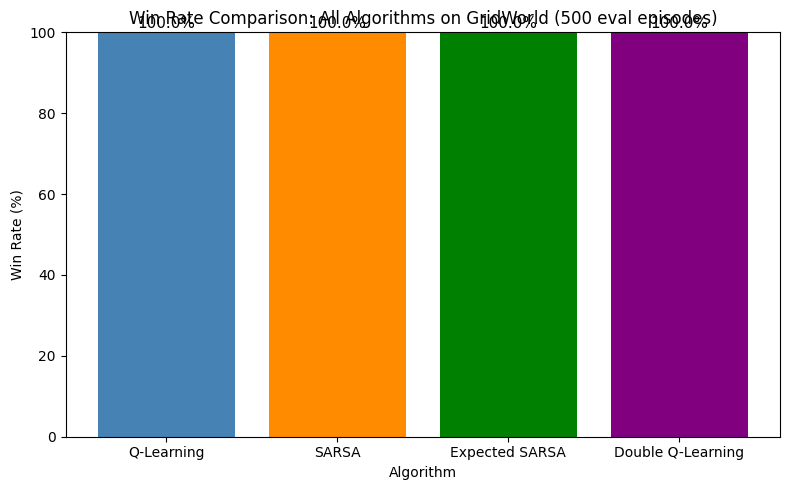

In [22]:
# Win rate comparison bar chart

# Packages all four evaluation result dictionaries into one list.
all_results = [ql_results, sarsa_results, esarsa_results, dql_results]
# A list comprehension that loops over all four result dictionaries and converts raw win counts into percentages.
win_rates = [r['Win'] / 500 * 100 for r in all_results]

plt.figure(figsize=(8, 5))
# labels : x-axis positions and tick labels for each bar
# win_rates : height of each bar
# color=colors : same color list used throughout: steelblue, darkorange, green, purple
bars = plt.bar(labels, win_rates, color=colors)
plt.title("Win Rate Comparison: All Algorithms on GridWorld (500 eval episodes)")
plt.xlabel("Algorithm")
plt.ylabel("Win Rate (%)")
# Forces the y-axis to go from 0 to 100 regardless of actual values.
# Important here because if all algorithms achieve 100% win rate, matplotlib might auto-scale to a very narrow range that makes tiny differences look huge.
plt.ylim(0, 100)

# This loop adds a text label above each bar.
for bar, rate in zip(bars, win_rates):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{rate:.1f}%", ha='center', fontsize=11)

# Adjust spacing and display.
plt.tight_layout()
plt.show()

---
## 7. Convergence Analysis

This section directly demonstrates the convergence theorem from Watkins & Dayan (1992),
which states that Q-values converge to the true optimal values $Q^*$ with probability 1.
Rather than just observing reward curves, we track the Q-values themselves for a specific
state over the course of training to show they stabilize, this is the empirical evidence
of convergence.

The theorem guarantees convergence under three conditions:

**Condition 1 — Bounded rewards:**rewards are bounded between -1 and +1.
$$|r_n| \leq \mathcal{R}, \quad \forall n$$

**Condition 2 — Learning rate conditions (Equation 3 from the paper):**
$$\sum_{i=1}^{\infty} \alpha_{n^i(x,a)} = \infty \quad \text{and} \quad \sum_{i=1}^{\infty} [\alpha_{n^i(x,a)}]^2 < \infty$$

Satisfied in our implementation by $\alpha = 1/N(x,a)$, since $\sum 1/n = \infty$
and $\sum 1/n^2 < \infty$.Our learning rate alpha equals 1 over N(x,a), satisfying both the harmonic series and Basel series conditions.

**Condition 3 — Infinite visitation:**
$$n^i(x, a) \rightarrow \infty \quad \text{as} \quad n \rightarrow \infty, \quad \forall x, a$$

Every state-action pair must be visited infinitely often. Ensured in our
implementation by keeping $\varepsilon_{\min} = 0.1$, so the epsilon never drops below 0.1, ensuring all state-action pairs are visited infinitely often.

When all three conditions hold, the theorem guarantees:

$$Q_n(x, a) \rightarrow Q^*(x, a) \quad \text{as} \quad n \rightarrow \infty, \quad \forall x, a \quad \text{with probability 1}$$

We visualize this in two ways. First, by tracking the Q-values of all four actions
at the start state (state 0) over 3000 episodes, they should start noisy and
gradually stabilize to fixed values, which is exactly what convergence means
in practice. Second, by plotting the effective learning rate $\alpha = 1/N(s=0,
a=\text{RIGHT})$ on a log scale , this shows the learning rate decaying toward
zero as visits accumulate, directly satisfying Condition 2 above.

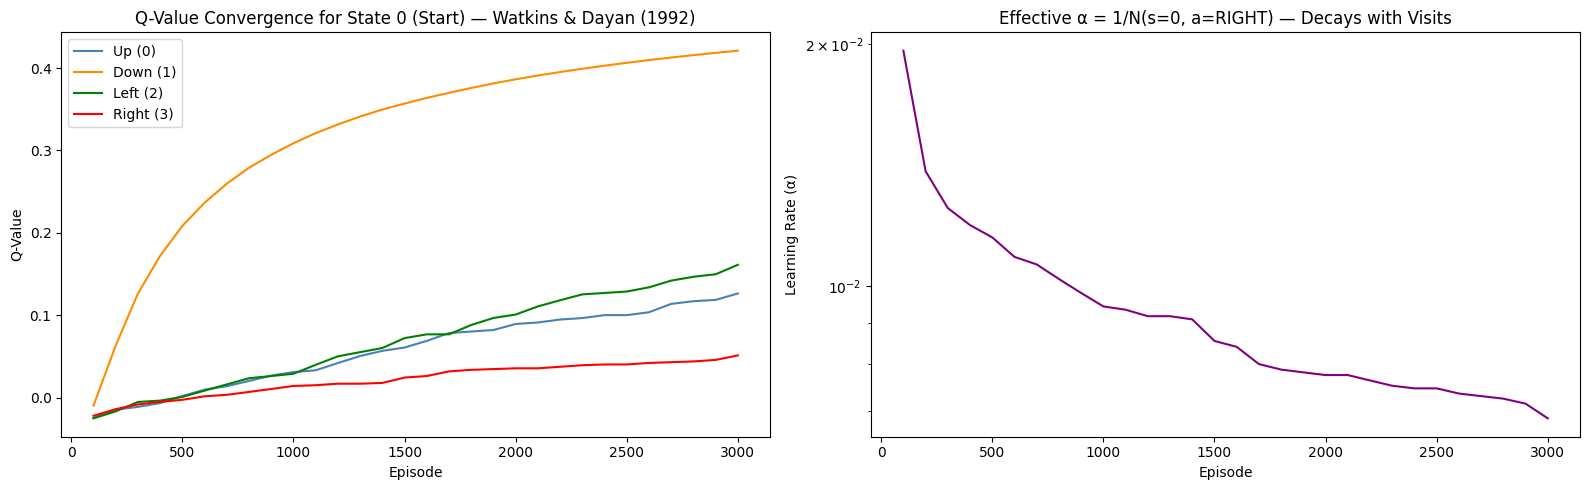


Final Q-values for state 0 (start):
  Up (0): Q=0.1264  N=160  α_final=0.00625
  Down (1): Q=0.4212  N=2998  α_final=0.000333555703802535
  Left (2): Q=0.1612  N=152  α_final=0.006578947368421052
  Right (3): Q=0.0511  N=146  α_final=0.00684931506849315
  Best action: Down (1)


In [23]:
# Convergence demo: track Q-values for a specific state over training
# We retrain Q-Learning from scratch and take snapshots every 100 episodes.

# Fresh environment and fresh Q-Learning agent specifically for this convergence demonstration.
env = GridWorld()
# No alpha: learning rate decays automatically via visit counts
agent_conv = QLearningAgent(n_states=env.n_states, n_actions=env.n_actions)

episodes = 3000
# Track Q-values for state 0 (start state) at regular intervals
# instead of recording every episode, take a snapshot every 100 episodes.
# This gives 30 data points across 3000 episodes, enough to see the convergence trend clearly without storing too much data
snapshot_interval = 100
# will store (episode_number, Q-values for state 0) pairs
q_snapshots = []       # (episode, Q-values for state 0)
# will store (episode_number, effective alpha for state 0 action RIGHT) pairs
alpha_snapshots = []   # (episode, effective alpha for state 0, action RIGHT)

# Identical training loop to the main Q-Learning training cell.
for ep in range(episodes):
    state = env.reset()
    done = False
    while not done:
        action = agent_conv.choose_action(state)
        next_state, reward, done = env.step(action)
        agent_conv.update(state, action, reward, next_state, done)
        state = next_state
    agent_conv.decay_epsilon()

    # Taking Snapshots
    # (ep + 1) % 100 == 0 is True at episodes 100, 200, 300... 3000. The ep + 1 is because ep starts at 0, so episode 1 is ep=0.
    if (ep + 1) % snapshot_interval == 0:
        # Records the current Q-values for state 0 at this episode.
        # .copy() is critical, without it, all snapshots would point to the same array in memory and would all show the final values by the time you plot them.
        q_snapshots.append((ep + 1, agent_conv.q_table[0].copy()))
        # Record effective alpha for state 0, action RIGHT (action 3)
        # how many times action RIGHT has been taken from state 0 so far
        n = agent_conv.visit_counts[0][3]
        # 1.0 / n : the current effective alpha
        # if n > 0 else 1.0 : safety check for the very first snapshot before state 0 action RIGHT has been visited at all
        alpha_snapshots.append((ep + 1, 1.0 / n if n > 0 else 1.0))

# Plot 1: Q-value convergence for state 0
action_labels = ['Up (0)', 'Down (1)', 'Left (2)', 'Right (3)']
action_colors = ['steelblue', 'darkorange', 'green', 'red']

# Extracts just the episode numbers from the snapshots list
episodes_tracked = [s[0] for s in q_snapshots]
q_vals_per_action = [[s[1][a] for s in q_snapshots] for a in range(4)]

# A nested list comprehension. For each action a (0 to 3), extract that action's Q-value across all 30 snapshots.
# Result is a list of 4 lists, each with 30 values: one value per snapshot per action.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left Plot: Q-Value Convergence
# Plots all four action Q-values for state 0 on the same axes. Each line shows how one action's Q-value estimate changed over 3000 episodes.
# This is the visual proof of convergence
for a in range(4):
    axes[0].plot(episodes_tracked, q_vals_per_action[a],
                 label=action_labels[a], color=action_colors[a])
axes[0].set_title("Q-Value Convergence for State 0 (Start) — Watkins & Dayan (1992)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Q-Value")
axes[0].legend()

# Plot 2: Effective learning rate decay for (state 0, action RIGHT)
# Extracts episode numbers and alpha values from the snapshots list separately.
alpha_eps   = [s[0] for s in alpha_snapshots]
alpha_vals  = [s[1] for s in alpha_snapshots]
# Plots the effective learning rate over episodes.
axes[1].plot(alpha_eps, alpha_vals, color='purple')
axes[1].set_title("Effective α = 1/N(s=0, a=RIGHT) — Decays with Visits")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Learning Rate (α)")
# Sets the y-axis to logarithmic scale. This is important because alpha decays as 1/N, on a linear scale the curve drops sharply at first and then becomes nearly flat and hard to read.
# On a log scale the decay appears as a straight line making it easy to see the rate of decrease across the full range of values.
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Prints three pieces of information for each action at state 0:
# Q : the final converged Q-value
# N: total number of visits accumulated over 3000 episodes
# α_final: the final effective learning rate = 1/N, showing how small it has become
print("\nFinal Q-values for state 0 (start):")
for a, label in enumerate(action_labels):
    visits = int(agent_conv.visit_counts[0][a])
    print(f"  {label}: Q={agent_conv.q_table[0][a]:.4f}  N={visits}  α_final={1/visits if visits>0 else 'N/A'}")
print(f"  Best action: {action_labels[int(np.argmax(agent_conv.q_table[0]))]}")

The left plot shows the Q-values for all four actions at state 0 over 3000 episodes. Early on they are noisy and spread apart. By the end they stabilize to fixed values, this stabilization is convergence.

The right plot shows the effective learning rate for state 0 action RIGHT on a logarithmic scale. It starts near 1.0 and decays steadily as visits accumulate, visually confirming the theorem's learning rate condition is satisfied.

The final print statements show the exact Q-values, visit counts, and final alpha for each action.

---
## 8. Hyperparameter Sensitivity (Q-Learning)

The convergence theorem in Watkins & Dayan (1992) proves that Q-Learning converges
to $Q^*$ with probability 1, but only under specific conditions on the learning rate.
The theorem requires:

$$\sum_{i=1}^{\infty} \alpha_{n^i(x,a)} = \infty \quad \text{and} \quad \sum_{i=1}^{\infty} [\alpha_{n^i(x,a)}]^2 < \infty$$

Our implementation satisfies this with the visit-count schedule:

$$\alpha_n(x,a) = \frac{1}{N(x,a)}$$

where $N(x,a)$ is the number of times state-action pair $(x,a)$ has been visited.
This satisfies both conditions because $\sum 1/n = \infty$ (harmonic series) and
$\sum 1/n^2 < \infty$ (Basel problem).

This section empirically demonstrates three things:

**1. Learning rate schedule comparison** — the paper-correct $\alpha = 1/N(x,a)$
is compared against fixed $\alpha \in \{0.01, 0.1, 0.5\}$ to show why the theorem's
conditions matter in practice.

**2. Discount factor sensitivity** — $\gamma \in \{0.9, 0.95, 0.99\}$ is varied to
show how the agent's time horizon affects convergence. $\gamma$ appears in every
Q-Learning update:

$$\text{target} = r + \gamma \max_{b} Q(s', b)$$

A higher $\gamma$ makes the agent value future rewards almost as much as immediate
ones, which slows convergence because Q-values take longer to stabilize across
longer time horizons.

**3. Exploration rate sensitivity** — initial $\varepsilon_0 \in \{0.1, 0.5, 1.0\}$
is varied to show how the starting exploration rate affects how quickly the agent
discovers good paths. $\varepsilon$ controls the epsilon-greedy action selection:

$$\pi(a|s) = \begin{cases} 1 - \varepsilon + \dfrac{\varepsilon}{|A|} & \text{if } a = \arg\max_b Q(s,b) \\ \dfrac{\varepsilon}{|A|} & \text{otherwise} \end{cases}$$

In all three experiments, the paper-correct visit-count learning rate is used
so that only one variable changes at a time.

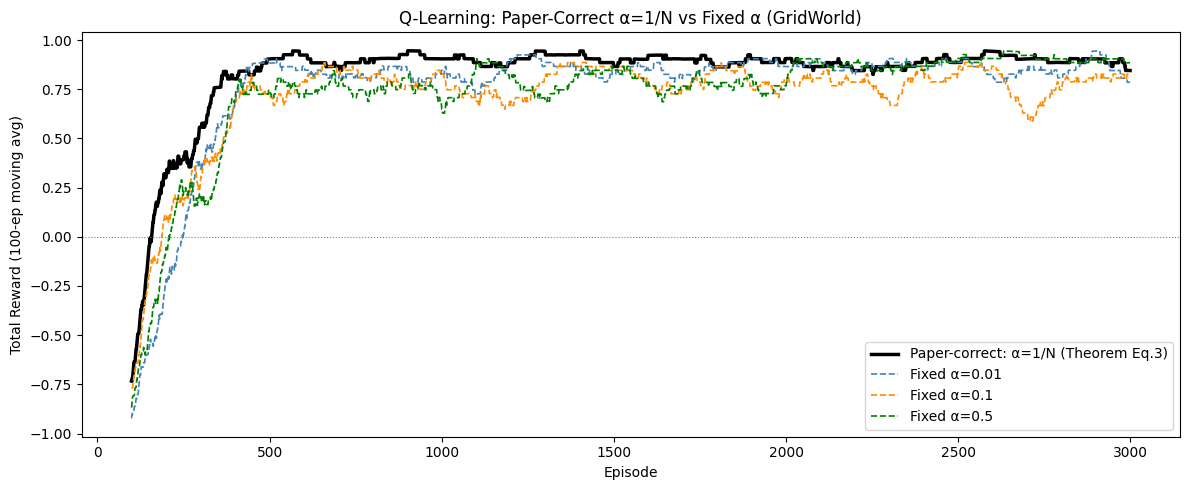

In [24]:
# Hyperparameter sensitivity: Paper-correct (1/N) vs fixed learning rates
# Since Q-Learning now uses visit-count alpha, we compare it against
# fixed-alpha agents to show WHY the paper's schedule matters

# A training function that runs Q-Learning with a fixed alpha.
def run_q_learning_fixed_alpha(alpha, gamma=0.9, epsilon_start=1.0, episodes=3000, seed=11):
    # Sets both random seeds to the same value before every run.
    # This ensures every agent,fixed alpha or visit-count,starts from exactly the same random state, making the comparison fair.
    random.seed(seed)
    np.random.seed(seed)
    # Creates a fresh environment and Q-table directly as local variables instead of using the QLearningAgent class.
    env = GridWorld()
    # Temporarily patch the update to use fixed alpha
    q_table = np.zeros((env.n_states, env.n_actions))
    epsilon = epsilon_start
    reward_history = []
    # epsilon-greedy action selection
    for ep in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            if random.random() < epsilon:
                action = random.randint(0, env.n_actions - 1)
            else:
                action = int(np.argmax(q_table[state]))
            next_state, reward, done = env.step(action)
            # reward if done: terminal target, just the final reward
            # reward + gamma * np.max(q_table[next_state]): Bellman target for non-terminal steps
            target = reward if done else reward + gamma * np.max(q_table[next_state])
            # += alpha * (target - q_table[state][action]) : fixed alpha update, alpha never changes regardless of how many times this pair has been visited
            q_table[state][action] += alpha * (target - q_table[state][action])
            state = next_state
            total_reward += reward
        epsilon = max(0.1, epsilon * 0.995)
        reward_history.append(total_reward)
    return reward_history


# Same structure as the fixed alpha function but uses the actual QLearningAgent class, which implements alpha = 1/N internally.
# No alpha parameter here because it is computed automatically from visit counts.
def run_q_learning_visit_count(gamma=0.9, epsilon_start=1.0, episodes=3000, seed=11):
    random.seed(seed)
    np.random.seed(seed)
    env = GridWorld()
    agent = QLearningAgent(n_states=env.n_states, n_actions=env.n_actions,
                           gamma=gamma, epsilon=epsilon_start)
    reward_history = []
    for ep in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
        agent.decay_epsilon()
        reward_history.append(total_reward)
    return reward_history

# Compare all schedules
schedules = [
    ('Paper-correct: α=1/N (Theorem Eq.3)', run_q_learning_visit_count(), 'black'),
    ('Fixed α=0.01', run_q_learning_fixed_alpha(alpha=0.01), 'steelblue'),
    ('Fixed α=0.1',  run_q_learning_fixed_alpha(alpha=0.1),  'darkorange'),
    ('Fixed α=0.5',  run_q_learning_fixed_alpha(alpha=0.5),  'green'),
]

plt.figure(figsize=(12, 5))
for label, hist, color in schedules:
    lw = 2.5 if 'Paper' in label else 1.2
    ls = '-'  if 'Paper' in label else '--'
    smoothed = pd.Series(hist).rolling(100).mean()
    plt.plot(smoothed, label=label, color=color, linewidth=lw, linestyle=ls)

plt.title("Q-Learning: Paper-Correct α=1/N vs Fixed α (GridWorld)")
plt.xlabel("Episode")
plt.ylabel("Total Reward (100-ep moving avg)")
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

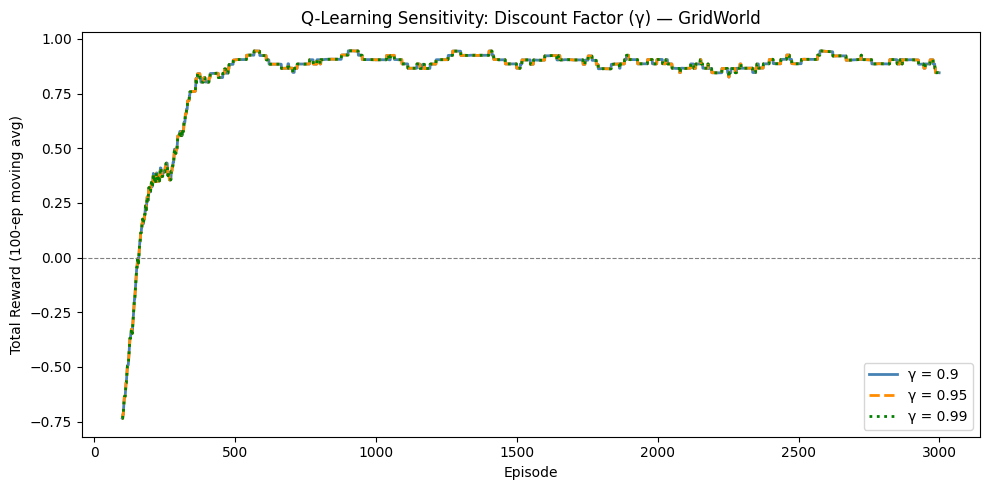

In [25]:
# Hyperparameter sensitivity: Discount factor (gamma)

# Three gamma values to test.
# 0.9: reward 10 steps away is worth 0.9^10 ≈ 35% of immediate reward
# 0.95: reward 10 steps away is worth 0.95^10 ≈ 60% of immediate reward
# 0.99: reward 10 steps away is worth 0.99^10 ≈ 90% of immediate reward
gammas = [0.9, 0.95, 0.99]
gamma_colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(10, 5))
# Training and Plotting Loop
linestyles = ['-', '--', ':']
for (gamma, color), ls in zip(zip(gammas, gamma_colors), linestyles):
    hist = run_q_learning_visit_count(gamma=gamma)
    smoothed = pd.Series(hist).rolling(100).mean()
    plt.plot(smoothed, label=f"γ = {gamma}", color=color, linestyle=ls, linewidth=2)

plt.title("Q-Learning Sensitivity: Discount Factor (γ) — GridWorld")
plt.xlabel("Episode")
plt.ylabel("Total Reward (100-ep moving avg)")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

The plot shows Q-Learning performance across three discount factors (γ = 0.9, 0.95, 0.99)
on the 4×4 GridWorld. All three curves are nearly identical, they converge at the same
speed, reach the same final reward (~0.9), and show the same noise pattern throughout
training. The three lines are visually indistinguishable even with different linestyles,
confirming they are learning the same policy.

This result is expected as the theorem's convergence guarantee holds for any γ ∈ (0, 1),
and GridWorld is simple enough that all three values of γ are sufficient to propagate
the goal reward (+1) back to the start state. With an optimal path of only 6–8 steps,
the discounted goal reward at the start state ranges from $0.9^6 ≈ 0.53$ to
$0.99^6 ≈ 0.94$ — all large enough to guide the agent correctly.

The  takeaway is that **gamma sensitivity only becomes meaningful in
environments with longer reward delays**, where a low γ causes the agent to undervalue
distant goals. In GridWorld, the goal is close enough that γ has no practical effect
on what the agent learns or how fast it learns it.

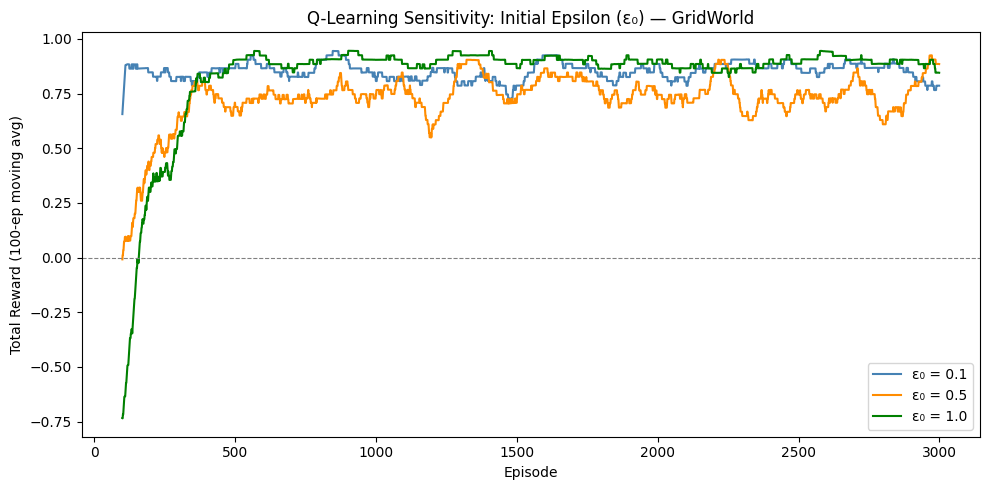

In [26]:
# Hyperparameter sensitivity: Initial epsilon (exploration)

# Three epsilon values to test.
epsilons = [0.1, 0.5, 1.0]
epsilon_colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(10, 5))
for eps, color in zip(epsilons, epsilon_colors):
    hist = run_q_learning_visit_count(epsilon_start=eps)
    smoothed = pd.Series(hist).rolling(100).mean()
    plt.plot(smoothed, label=f"ε₀ = {eps}", color=color)

plt.title("Q-Learning Sensitivity: Initial Epsilon (ε₀) — GridWorld")
plt.xlabel("Episode")
plt.ylabel("Total Reward (100-ep moving avg)")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

This shows that starting with full exploration, epsilon 1.0, converges most reliably because every state-action pair gets visited early, satisfying the theorem's infinite visitation condition.